# Roman CS Emulator Analysis

Loads and evaluates all trained ResCNN emulators for the Roman Space Telescope cosmic shear probe.
Covers scratch baselines (Taka, Mead2020), transfer learning scaling curves, pretrained model quality
comparisons, and freeze strategy sweeps.

**Workflow:**
1. Edit the CONFIG cell to control which groups/sizes to load
2. Run PLOT SETTINGS and LOADING cells once
3. Run whichever plot cells are relevant — each is independent

**Adding a new experiment:**
- Add an entry to `_CONFIGS` with the right `model_dir`, `model_prefix`, `test_dv`, `test_par`, `sizes`
- Add a `GROUP_STYLES` and `GROUP_LABELS` entry
- Add it to `groups_to_load` in the LOADING cell
- It will automatically appear in `plot_scaling()` and the summary table

In [1]:
# ============================================================================
# CONFIG
# Edit this cell to control what gets loaded and plotted.
# All paths are relative to BASE.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import h5py
import sys
from pathlib import Path

BASE = Path('/home/grads/tmp/roman_cs_baseline')
sys.path.insert(0, str(BASE))
from emulator import ResCNN

# --------------------------------------------------------------------------
# Toggle groups on/off — set False to skip loading entirely
# --------------------------------------------------------------------------
INCLUDE_TAKA          = True
INCLUDE_MEAD          = True
INCLUDE_TL            = True      # TL from Taka 100k, no freeze
INCLUDE_TL_EARLY2     = True      # TL from Taka 100k, early_2 freeze
INCLUDE_TL_TAKA50K    = True      # TL from Taka  50k, no freeze
INCLUDE_TL_TAKA250K   = True      # TL from Taka 250k, no freeze
INCLUDE_FREEZE_SWEEP  = True      # Freeze strategy sweep (loads separately — see FREEZE SWEEP cell)
INCLUDE_TAKA_RESMLP        = True
INCLUDE_MEAD_RESMLP        = True
INCLUDE_TL_RESMLP_TAKA50K  = True
INCLUDE_TL_RESMLP_TAKA100K = True
INCLUDE_TL_RESMLP_TAKA250K = True
INCLUDE_TL_RESMLP_TAKA500K = True

# --------------------------------------------------------------------------
# Sizes to load per group — set to None to use all available
# --------------------------------------------------------------------------
TAKA_SIZES      = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
MEAD_SIZES      = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
TL_SIZES        = [1_000, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
TL_E2_SIZES     = [10_000, 25_000, 50_000]
TL_TAKA50K_SIZES  = [1_000, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
TL_TAKA250K_SIZES = [1_000, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]

# Freeze strategy sweep — fixed N_train, all strategies
# These are loaded separately in the FREEZE SWEEP cell below.
FREEZE_SWEEP_N_TRAIN   = 10_000
FREEZE_SWEEP_STRATEGIES = [
    'none', 'early_1', 'early_2', 'early_3', 'early_4', 'early_5', 'early_6',
    'late_1', 'late_2', 'late_3', 'late_4', 'late_5', 'late_6',
    'input_output', 'resnet_123', 'cnn_only', 'cnn_all'
]

# --------------------------------------------------------------------------
# Test data paths
# --------------------------------------------------------------------------
_TAKA_TEST_DV  = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm_taka/roman_real_lcdm_b_taka_test_datavectors.npy')
_TAKA_TEST_PAR = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm_taka/roman_real_lcdm_b_taka_test_parameters.txt')
_MEAD_TEST_DV  = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm/test/roman_real_lcdm_b_test_datavectors.npy')
_MEAD_TEST_PAR = Path('/home/grads/backup/mltraining/yijie/roman_3x2_lcdm/test/roman_real_lcdm_b_test_parameters.txt')

# --------------------------------------------------------------------------
# Experiment registry
# To add a new experiment: add an entry here + a GROUP_STYLES/GROUP_LABELS entry below.
# Fields:
#   model_dir     : directory containing .pt and .h5 files
#   model_prefix  : filename prefix before _N{size}.pt
#   log_file      : path to training log (or list of paths); None = skip log parsing
#   test_dv       : path to test data vectors .npy
#   test_par      : path to test parameters .txt
#   n_dv          : number of data vector elements (1080 for cosmic shear)
#   sizes         : list of N_train values to load
#   shared_h5     : if all runs share one .h5 (e.g. same normalization), set path here;
#                   None = each run has its own .h5 (correct for TL runs)
# --------------------------------------------------------------------------
_CONFIGS = {
    'taka': {
        'model_dir':    BASE / 'output_taka' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka',
        'log_file':     BASE / 'sweep_taka.log',
        'test_dv':      _TAKA_TEST_DV,
        'test_par':     _TAKA_TEST_PAR,
        'n_dv':         1080,
        'sizes':        TAKA_SIZES,
        'shared_h5':    None,
    },
    'mead': {
        'model_dir':    BASE / 'output_mead' / 'models',
        'model_prefix': 'roman_cs_lcdm_mead',
        'log_file':     [BASE / 'sweep_mead_small.log', BASE / 'sweep_mead.log'],
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        MEAD_SIZES,
        'shared_h5':    None,
    },
    # TL: Taka 100k pretrained, no freeze
    'tl': {
        'model_dir':    BASE / 'output_tl' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        TL_SIZES,
        'shared_h5':    None,   # each TL run saves its own .h5 with pretrained normalization
    },
    # TL: Taka 100k pretrained, early_2 freeze
    'tl_early2': {
        'model_dir':    BASE / 'output_tl_early2' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        TL_E2_SIZES,
        'shared_h5':    None,
    },
    # TL: Taka 50k pretrained, no freeze (weaker init — Vivian's request)
    'tl_taka50k': {
        'model_dir':    BASE / 'output_tl_taka50k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        TL_TAKA50K_SIZES,
        'shared_h5':    None,
    },
    # TL: Taka 250k pretrained, no freeze (stronger init — Vivian's request)
    'tl_taka250k': {
        'model_dir':    BASE / 'output_tl_taka250k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        TL_TAKA250K_SIZES,
        'shared_h5':    None,
    },

    # --------------------------------------------------------------------------
    # ResMLP scratch baselines
    # --------------------------------------------------------------------------
    'taka_resmlp': {
        'model_dir':    BASE / 'output_taka_resmlp' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka_resmlp',
        'log_file':     BASE / 'sweep_taka_resmlp.log',
        'test_dv':      _TAKA_TEST_DV,
        'test_par':     _TAKA_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
    'mead_resmlp': {
        'model_dir':    BASE / 'output_mead_resmlp' / 'models',
        'model_prefix': 'roman_cs_lcdm_mead_resmlp',
        'log_file':     BASE / 'sweep_mead_resmlp.log',
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
    # --------------------------------------------------------------------------
    # ResMLP TL: taka_resmlp -> mead, varying pretrained quality (placeholders)
    # --------------------------------------------------------------------------
    'tl_resmlp_taka50k': {
        'model_dir':    BASE / 'output_tl_resmlp_taka50k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_resmlp_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
    'tl_resmlp_taka100k': {
        'model_dir':    BASE / 'output_tl_resmlp_taka100k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_resmlp_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
    'tl_resmlp_taka250k': {
        'model_dir':    BASE / 'output_tl_resmlp_taka250k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_resmlp_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
    'tl_resmlp_taka500k': {
        'model_dir':    BASE / 'output_tl_resmlp_taka500k' / 'models',
        'model_prefix': 'roman_cs_lcdm_taka2mead_resmlp_TL',
        'log_file':     None,
        'test_dv':      _MEAD_TEST_DV,
        'test_par':     _MEAD_TEST_PAR,
        'n_dv':         1080,
        'sizes':        [1_000, 2_500, 5_000, 7_500, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000],
        'shared_h5':    None,
    },
}

OUTPUT_DIR = BASE / 'output_combined'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Config loaded.')
for g, c in _CONFIGS.items():
    print(f'  {g}: model_dir exists={c["model_dir"].exists()}')

Config loaded.
  taka: model_dir exists=True
  mead: model_dir exists=True
  tl: model_dir exists=True
  tl_early2: model_dir exists=True
  tl_taka50k: model_dir exists=True
  tl_taka250k: model_dir exists=True


In [2]:
# ============================================================================
# PLOT SETTINGS
# Global matplotlib config + color/style registries.
# To add a new group: add entries to GROUP_STYLES and GROUP_LABELS.
# ============================================================================
plt.rcParams['mathtext.fontset']    = 'stix'
plt.rcParams['font.family']         = 'STIXGeneral'
plt.rcParams['xtick.bottom']        = True
plt.rcParams['xtick.top']           = False
plt.rcParams['ytick.right']         = False
plt.rcParams['axes.edgecolor']      = 'black'
plt.rcParams['axes.linewidth']      = '1.0'
plt.rcParams['axes.grid']           = True
plt.rcParams['grid.linewidth']      = '0.0'
plt.rcParams['grid.alpha']          = '0.18'
plt.rcParams['grid.color']          = 'lightgray'
plt.rcParams['legend.labelspacing'] = 0.77
plt.rcParams['savefig.bbox']        = 'tight'
plt.rcParams['savefig.format']      = 'pdf'
plt.rcParams['text.usetex']         = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'
plt.rcParams.update({
    'font.size':        18,
    'axes.labelsize':   30,
    'axes.titlesize':   34,
    'xtick.labelsize':  26,
    'ytick.labelsize':  26,
    'legend.fontsize':  20,
    'figure.titlesize': 38,
})

# --------------------------------------------------------------------------
# Style registry — one entry per group key
# color    : line/marker color
# marker   : matplotlib marker string
# linestyle: '-', '--', ':', '-.'
# Solid lines = scratch baselines; dashed = TL no-freeze; dotted = TL frozen
# Color families: orange=Taka, blue=Mead, purple=TL 100k, red=TL 50k, green=TL 250k
# --------------------------------------------------------------------------
GROUP_STYLES = {
    'taka':        dict(color='#F18F01', marker='o',  linestyle='-'),
    'mead':        dict(color='#2E86AB', marker='s',  linestyle='-'),
    'tl':          dict(color='#A23B72', marker='^',  linestyle='--'),   # 100k init, no freeze
    'tl_early2':   dict(color='#A23B72', marker='v',  linestyle=':'),    # 100k init, early_2
    'tl_taka50k':  dict(color='#E84855', marker='^',  linestyle='--'),   # 50k  init, no freeze
    'tl_taka250k': dict(color='#3BB273', marker='^',  linestyle='--'),   # 250k init, no freeze
    # ResMLP scratch — same hue as CNN counterpart, diamond marker, dashed
    'taka_resmlp':        dict(color='#F18F01', marker='D',  linestyle='--'),
    'mead_resmlp':        dict(color='#2E86AB', marker='D',  linestyle='--'),
    # ResMLP TL — green family, varying shade by init quality
    'tl_resmlp_taka50k':  dict(color='#A8D8A8', marker='^',  linestyle='--'),
    'tl_resmlp_taka100k': dict(color='#5BAD6F', marker='^',  linestyle='--'),
    'tl_resmlp_taka250k': dict(color='#2E7D32', marker='^',  linestyle='--'),
    'tl_resmlp_taka500k': dict(color='#1B5E20', marker='^',  linestyle='--'),
}

GROUP_LABELS = {
    'taka':        r'Taka (scratch)',
    'mead':        r'Mead (scratch)',
    'tl':          r'TL Taka$_{100\mathrm{k}}\to$Mead',
    'tl_early2':   r'TL Taka$_{100\mathrm{k}}\to$Mead (early\_2)',
    'tl_taka50k':  r'TL Taka$_{50\mathrm{k}}\to$Mead',
    'tl_taka250k': r'TL Taka$_{250\mathrm{k}}\to$Mead',
    'taka_resmlp':        r'Taka ResMLP (scratch)',
    'mead_resmlp':        r'Mead ResMLP (scratch)',
    'tl_resmlp_taka50k':  r'TL ResMLP Taka$_{50\mathrm{k}}\to$Mead',
    'tl_resmlp_taka100k': r'TL ResMLP Taka$_{100\mathrm{k}}\to$Mead',
    'tl_resmlp_taka250k': r'TL ResMLP Taka$_{250\mathrm{k}}\to$Mead',
    'tl_resmlp_taka500k': r'TL ResMLP Taka$_{500\mathrm{k}}\to$Mead',
}

def fmt_n(n):
    """Human-readable N_train label (no dollar signs — caller adds math mode if needed)."""
    if n >= 1_000_000: return r'10^{6}'
    if n >= 1_000:     return f'{n // 1000}\\mathrm{{k}}'
    return str(n)

print('Plot settings loaded.')

Plot settings loaded.


In [3]:
# ============================================================================
# LOADING — inference-based Δχ² computation
# Loads each model, runs it on the test set, computes per-sample Δχ².
# Also parses training logs for a quick sanity check (log median vs inference median).
#
# Results stored in:
#   results[group][n_train] = np.ndarray of Δχ² values (one per test point)
#   log_results[group][n_train] = {'mean', 'median', 'n_outliers'} from training log
#
# Disk cache: Δχ² arrays are saved to OUTPUT_DIR/results_cache.npz after each run.
# On re-runs, only missing (group, n_train) entries are recomputed — already-evaluated
# models are loaded instantly from the cache.
# To force a specific entry to recompute: del results[group][n_train], then re-run.
# To wipe everything: delete results_cache.npz.
#
# Test data is also cached in-memory keyed by file path — each unique test set
# (taka, mead) is only loaded from disk once per session.
# ============================================================================

RESULTS_CACHE = OUTPUT_DIR / 'results_cache.npz'

# --------------------------------------------------------------------------
# In-memory test data cache — keyed by (test_dv_path, test_par_path)
# Populated lazily on first access; persists across run_inference calls.
# --------------------------------------------------------------------------
_test_data_cache = {}

def get_test_data(test_dv, test_par, n_dv):
    """
    Load and cache test data by file path. Returns (x_raw, y_raw, header).
    x_raw and y_raw are unprocessed — normalization is applied per-model in
    run_inference since each model has its own preprocessing parameters.
    """
    key = (str(test_dv), str(test_par))
    if key not in _test_data_cache:
        print(f'    [cache miss] loading test data: {Path(test_par).name}')
        header = np.array(open(test_par).readline().split(' ')[1:])
        header[-1] = header[-1].strip()
        x_raw = torch.tensor(np.loadtxt(test_par), dtype=torch.float32)
        y_raw = torch.tensor(np.load(test_dv)[:, :n_dv], dtype=torch.float32)
        _test_data_cache[key] = (x_raw, y_raw, header)
    return _test_data_cache[key]


def parse_log(log_file_or_list):
    """
    Parse training log(s) for quick median/mean/outlier sanity checks.
    Accepts a single path or a list of paths (results merged; later files win on overlap).
    Returns {n_train: {'mean', 'median', 'n_outliers'}} or {} if no log.
    """
    if log_file_or_list is None:
        return {}
    log_files = log_file_or_list if isinstance(log_file_or_list, list) else [log_file_or_list]
    parsed = {}
    for log_file in log_files:
        if log_file is None or not Path(log_file).exists():
            continue
        current_n = None
        with open(log_file) as f:
            for line in f:
                if 'N_train =' in line:
                    current_n = int(line.strip().split('N_train = ')[1])
                    parsed[current_n] = {}
                if current_n is None:
                    continue
                if 'Mean   Delta Chi2' in line:
                    parsed[current_n]['mean']       = float(line.strip().split('= ')[1])
                if 'Median Delta Chi2' in line:
                    parsed[current_n]['median']     = float(line.strip().split('= ')[1])
                if 'N points with Chi2 > 0.2' in line:
                    parsed[current_n]['n_outliers'] = int(line.strip().split(': ')[1])
    return parsed


def run_inference(group_key, n_train):
    """
    Load a ResCNN model and return per-sample Δχ² on the test set.
    Returns None if the model files are missing.
    Uses cached test data — only reads from disk on first call per unique test set.

    Δχ² = ||ŷ_norm - y_norm||² where y_norm = (y - y_fid) @ V / sqrt(λ)
    and V, λ are the eigenvectors/eigenvalues of the covariance matrix.
    This equals the standard cosmological chi-squared under the Gaussian likelihood.
    """
    cfg     = _CONFIGS[group_key]
    n_dv    = cfg['n_dv']
    pt_path = cfg['model_dir'] / f"{cfg['model_prefix']}_N{n_train}.pt"
    h5_path = cfg['shared_h5'] or (cfg['model_dir'] / f"{cfg['model_prefix']}_N{n_train}.h5")

    if not pt_path.exists():
        print(f'    [skip] not found: {pt_path.name}')
        return None
    if not h5_path.exists():
        print(f'    [skip] h5 not found: {h5_path.name}')
        return None

    # Load normalization + covariance decomposition from h5
    with h5py.File(h5_path) as f:
        samples_mean = torch.tensor(f['sample_mean'][:], dtype=torch.float32)
        samples_std  = torch.tensor(f['sample_std'][:],  dtype=torch.float32)
        dv_evals     = torch.tensor(f['dv_evals'][:],    dtype=torch.float32)
        dv_evecs     = torch.tensor(f['dv_evecs'][:],    dtype=torch.float32)
        dv_fid       = torch.tensor(f['dv_fid'][:],      dtype=torch.float32)
        train_params = [p.decode() if isinstance(p, bytes) else p for p in f['train_params'][:]]

    # Get test data from in-memory cache
    x_raw, y_raw, header = get_test_data(cfg['test_dv'], cfg['test_par'], n_dv)

    # Select and reorder parameter columns to match what this model was trained on
    idxs   = [np.where(header == p)[0][0] for p in train_params]
    x_test = x_raw[:, idxs]
    y_test = y_raw[:, :n_dv]

    # Preprocess — must match exactly what train_emulator.py does
    x_test      = (x_test - samples_mean) / samples_std
    y_test_norm = (y_test - dv_fid) @ dv_evecs / dv_evals

    # Dispatch architecture by group key
    from emulator import ResMLP
    if 'resmlp' in group_key:
        model = ResMLP(len(train_params), n_dv, 512)
    else:
        model = ResCNN(len(train_params), n_dv, 256, 576, 21, 1)
    model.load_state_dict(torch.load(pt_path, map_location='cpu'))
    model.eval()

    with torch.no_grad():
        diff = y_test_norm - model(x_test)
    return (diff ** 2).sum(dim=1).numpy()


# --------------------------------------------------------------------------
# Load disk cache if available — only missing entries will be recomputed
# --------------------------------------------------------------------------
if RESULTS_CACHE.exists():
    _cached = np.load(RESULTS_CACHE, allow_pickle=True)
    results = _cached['results'].item()
    n_cached = sum(len(v) for v in results.values())
    print(f'Loaded disk cache: {n_cached} entries across {list(results.keys())}')
else:
    results = {}
    print('No disk cache found — will run full inference.')

log_results = {}   # always re-parsed (fast)

groups_to_load = [g for g, flag in [
    ('taka',        INCLUDE_TAKA),
    ('mead',        INCLUDE_MEAD),
    ('tl',          INCLUDE_TL),
    ('tl_early2',   INCLUDE_TL_EARLY2),
    ('tl_taka50k',  INCLUDE_TL_TAKA50K),
    ('tl_taka250k', INCLUDE_TL_TAKA250K),
] if flag]

new_entries = 0
for group in groups_to_load:
    if group not in results:
        results[group] = {}
    log_results[group] = parse_log(_CONFIGS[group].get('log_file'))
    print(f'\n=== {group.upper()} ===')

    for n in _CONFIGS[group]['sizes']:
        # Already cached — just print summary and skip
        if n in results[group]:
            dc2 = results[group][n]
            print(f'  N={n:>9,}: [cached] median={np.median(dc2):.4f}, f>0.2={np.mean(dc2 > 0.2):.3f}')
            continue

        # Not cached — run inference
        in_log  = n in log_results[group]
        log_med = log_results[group][n].get('median', float('nan')) if in_log else float('nan')
        src     = f'log median={log_med:.4f}, running inference...' if in_log else 'running inference...'
        print(f'  N={n:>9,}: {src}')

        dc2 = run_inference(group, n)
        if dc2 is not None:
            results[group][n] = dc2
            new_entries += 1
            inf_med = np.median(dc2)
            note = ''
            if in_log and not np.isnan(log_med):
                flag = '\u2713' if abs(inf_med - log_med) < 0.01 else '\u26a0 MISMATCH'
                note = f'  (log={log_med:.4f} {flag})'
            print(f'    \u2192 median={inf_med:.4f}, f>0.2={np.mean(dc2 > 0.2):.3f}{note}')

# Save updated cache to disk
if new_entries > 0:
    np.savez(RESULTS_CACHE, results=results)
    print(f'\nSaved {new_entries} new entries to cache: {RESULTS_CACHE}')
else:
    print('\nAll entries were cached — no inference needed.')
print(f'Test data loaded from disk: {[Path(k[1]).name for k in _test_data_cache]}')

Loaded disk cache: 35 entries across ['taka', 'mead', 'tl', 'tl_early2', 'tl_taka50k', 'tl_taka250k']

=== TAKA ===
  N=   10,000: [cached] median=0.1439, f>0.2=0.335
  N=   25,000: [cached] median=0.0440, f>0.2=0.047
  N=   50,000: [cached] median=0.0160, f>0.2=0.013
  N=  100,000: [cached] median=0.0076, f>0.2=0.007
  N=  250,000: [cached] median=0.0020, f>0.2=0.002
  N=  500,000: [cached] median=0.0015, f>0.2=0.002
  N=1,000,000: [cached] median=0.0012, f>0.2=0.000

=== MEAD ===
  N=   10,000: [cached] median=0.1530, f>0.2=0.368
  N=   25,000: [cached] median=0.0398, f>0.2=0.038
  N=   50,000: [cached] median=0.0141, f>0.2=0.010
  N=  100,000: [cached] median=0.0025, f>0.2=0.002
  N=  250,000: [cached] median=0.0009, f>0.2=0.001
  N=  500,000: [cached] median=0.0003, f>0.2=0.001
  N=1,000,000: [cached] median=0.0002, f>0.2=0.000

=== TL ===
  N=    1,000: [cached] median=0.4851, f>0.2=0.833
  N=   10,000: [cached] median=0.0303, f>0.2=0.043
  N=   25,000: [cached] median=0.0089, f>0

In [26]:
# ============================================================================
# ZERO-SHOT BASELINE
# Evaluates the Taka 1M model directly on Mead test data without any fine-tuning.
# This is the "no TL" baseline — shows how bad cross-domain transfer is without adaptation.
# Only needs to run once; dc2_zeroshot is used by plot_scaling().
# ============================================================================
ZS_PT = BASE / 'output_taka/models/roman_cs_lcdm_taka_N250000.pt'
ZS_H5 = BASE / 'output_taka/models/roman_cs_lcdm_taka_N250000.h5'

with h5py.File(ZS_H5) as f:
    zs_mean       = torch.tensor(f['sample_mean'][:], dtype=torch.float32)
    zs_std        = torch.tensor(f['sample_std'][:],  dtype=torch.float32)
    zs_evals      = torch.tensor(f['dv_evals'][:],    dtype=torch.float32)
    zs_evecs      = torch.tensor(f['dv_evecs'][:],    dtype=torch.float32)
    zs_fid        = torch.tensor(f['dv_fid'][:],      dtype=torch.float32)
    zs_params     = [p.decode() if isinstance(p, bytes) else p for p in f['train_params'][:]]

header = np.array(open(_MEAD_TEST_PAR).readline().split(' ')[1:])
header[-1] = header[-1].strip()
idxs = [np.where(header == p)[0][0] for p in zs_params]

x_zs = torch.tensor(np.loadtxt(_MEAD_TEST_PAR)[:, idxs], dtype=torch.float32)
y_zs = torch.tensor(np.load(_MEAD_TEST_DV)[:, :1080],    dtype=torch.float32)

# Use Taka normalization but evaluate on Mead test data
x_zs = (x_zs - zs_mean) / zs_std
y_zs_norm = (y_zs - zs_fid) @ zs_evecs / zs_evals

zs_model = ResCNN(len(zs_params), 1080, 256, 576, 21, 1)
zs_model.load_state_dict(torch.load(ZS_PT, map_location='cpu'))
zs_model.eval()
with torch.no_grad():
    diff = y_zs_norm - zs_model(x_zs)
dc2_zeroshot = (diff ** 2).sum(dim=1).numpy()

print(f'Zero-shot Taka 1M -> Mead:')
print(f'  Median  Δχ² = {np.median(dc2_zeroshot):.4f}')
print(f'  f(>0.2) = {np.mean(dc2_zeroshot > 0.2):.4f}')

Zero-shot Taka 1M -> Mead:
  Median  Δχ² = 29.8374
  f(>0.2) = 0.9986


In [5]:
# ============================================================================
# FREEZE SWEEP LOADING
# Separate from the main loading loop because the model naming convention
# is different (strategy name instead of N_train in the filename).
#
# Results stored in:
#   freeze_results[strategy] = np.ndarray of Δχ² values
#
# Only run this cell if INCLUDE_FREEZE_SWEEP = True and the sweep is done.
# ============================================================================
if INCLUDE_FREEZE_SWEEP:
    FREEZE_SWEEP_DIR = BASE / 'output_freeze_sweep' / 'models'
    freeze_results = {}

    for strategy in FREEZE_SWEEP_STRATEGIES:
        pt_path = FREEZE_SWEEP_DIR / f'roman_cs_lcdm_taka2mead_TL_{strategy}.pt'
        h5_path = FREEZE_SWEEP_DIR / f'roman_cs_lcdm_taka2mead_TL_{strategy}.h5'

        if not pt_path.exists():
            print(f'  [skip] {strategy}: .pt not found')
            continue
        if not h5_path.exists():
            print(f'  [skip] {strategy}: .h5 not found')
            continue

        with h5py.File(h5_path) as f:
            samples_mean = torch.tensor(f['sample_mean'][:], dtype=torch.float32)
            samples_std  = torch.tensor(f['sample_std'][:],  dtype=torch.float32)
            dv_evals     = torch.tensor(f['dv_evals'][:],    dtype=torch.float32)
            dv_evecs     = torch.tensor(f['dv_evecs'][:],    dtype=torch.float32)
            dv_fid       = torch.tensor(f['dv_fid'][:],      dtype=torch.float32)
            train_params = [p.decode() if isinstance(p, bytes) else p for p in f['train_params'][:]]

        header = np.array(open(_MEAD_TEST_PAR).readline().split(' ')[1:])
        header[-1] = header[-1].strip()
        idxs = [np.where(header == p)[0][0] for p in train_params]

        x_test = torch.tensor(np.loadtxt(_MEAD_TEST_PAR)[:, idxs], dtype=torch.float32)
        y_test = torch.tensor(np.load(_MEAD_TEST_DV)[:, :1080],    dtype=torch.float32)

        x_test      = (x_test - samples_mean) / samples_std
        y_test_norm = (y_test - dv_fid) @ dv_evecs / dv_evals

        model = ResCNN(len(train_params), 1080, 256, 576, 21, 1)
        model.load_state_dict(torch.load(pt_path, map_location='cpu'))
        model.eval()
        with torch.no_grad():
            diff = y_test_norm - model(x_test)
        dc2 = (diff ** 2).sum(dim=1).numpy()
        freeze_results[strategy] = dc2
        print(f'  {strategy:<20} median={np.median(dc2):.4f}  f>0.2={np.mean(dc2 > 0.2):.3f}')

    print(f'\nLoaded {len(freeze_results)}/{len(FREEZE_SWEEP_STRATEGIES)} strategies.')
else:
    freeze_results = {}
    print('Freeze sweep not loaded (INCLUDE_FREEZE_SWEEP = False).')

  none                 median=0.0219  f>0.2=0.029
  early_1              median=0.0346  f>0.2=0.038
  early_2              median=0.0639  f>0.2=0.122
  early_3              median=0.1057  f>0.2=0.226
  early_4              median=0.5986  f>0.2=0.932
  early_5              median=24.4180  f>0.2=1.000
  early_6              median=110.2888  f>0.2=1.000
  late_1               median=0.0820  f>0.2=0.081
  late_2               median=0.0919  f>0.2=0.086
  late_3               median=0.3306  f>0.2=0.898
  late_4               median=0.5271  f>0.2=0.979
  late_5               median=0.9153  f>0.2=0.994
  late_6               median=1.8606  f>0.2=1.000
  input_output         median=0.0925  f>0.2=0.109
  resnet_123           median=0.1317  f>0.2=0.327
  cnn_only             median=0.0246  f>0.2=0.034
  cnn_all              median=0.0190  f>0.2=0.022

Loaded 17/17 strategies.


---
## Plots

Each plot cell is self-contained — run any of them independently after loading.
All `save=True` outputs go to `OUTPUT_DIR`.

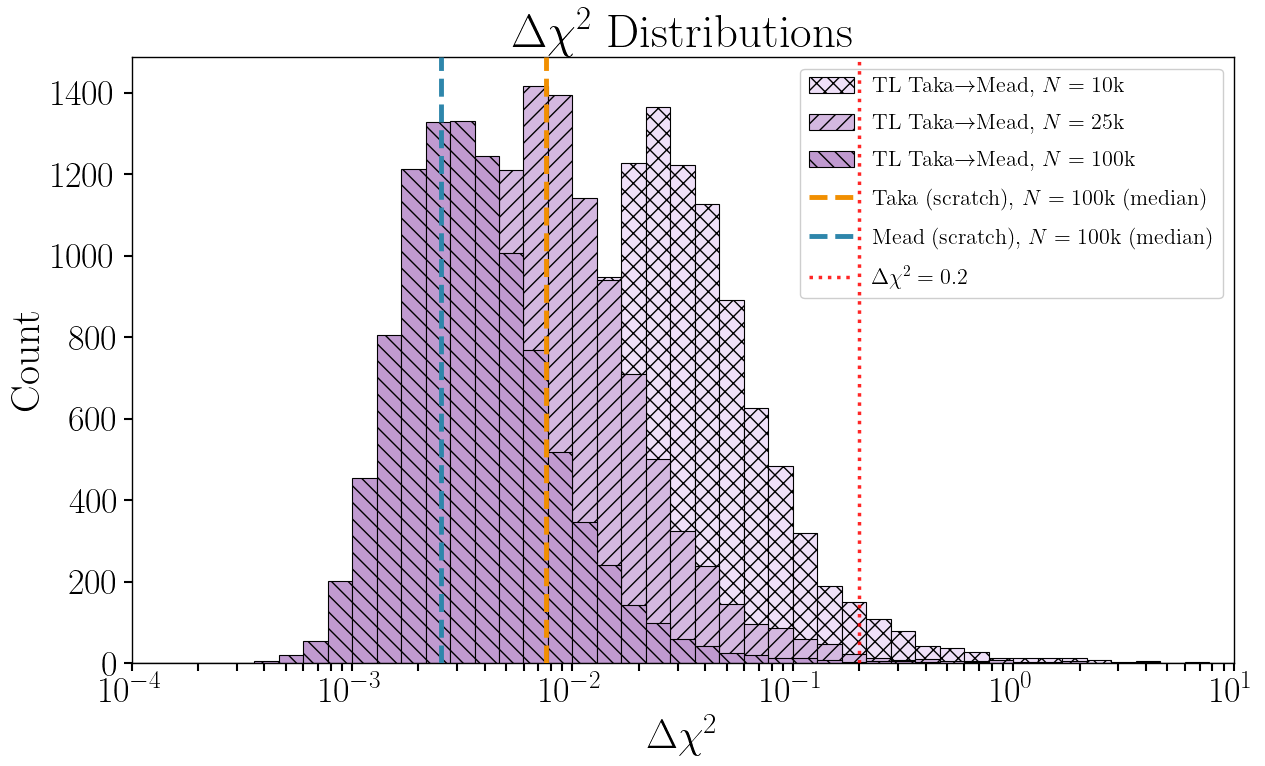

In [6]:
# ============================================================================
# PLOT: Δχ² DISTRIBUTIONS
# Overlapping histograms for a selected subset of groups and N_train values.
# Good for showing the full distribution shape, not just summary statistics.
#
# Edit DIST_GROUPS and DIST_N_PER_GROUP to control what appears.
# ============================================================================

# Which groups and which sizes to show in the histogram
# None = all loaded sizes for that group
DIST_GROUPS = {
    'taka':        [100_000],
    'mead':        [100_000],
    'tl':          [10_000, 25_000, 100_000],
}
DIST_ANCHOR_N = 100_000   # N shown as vertical reference line for scratch baselines

# TL-specific histogram colors (light to dark = small to large N)
_TL_COLORS  = ['#EFE0F8', '#D4B8E0', '#C09AD0', '#A87DC0', '#9B6DBF', '#7A4A9E', '#5B2182', '#3D1060']
_TL_HATCHES = ['xx', '//', '\\\\', '..', 'xx', '//', '\\\\', '..']


def plot_distributions(groups_config=DIST_GROUPS, anchor_n=DIST_ANCHOR_N,
                       tl_group='tl', save=False):
    """
    Histogram of Δχ² distributions.
    `groups_config`: dict of {group_key: [n_train list] or None}
    Scratch groups (taka, mead) are shown as vertical median lines at `anchor_n`.
    TL groups are shown as filled histograms, light-to-dark by N_train.
    """
    fig, ax = plt.subplots(figsize=(13, 8))
    bins = np.logspace(-4, 2, 55)

    # TL histograms — worst (smallest N) first so best sits on top
    if tl_group in results and tl_group in groups_config:
        sizes_to_show = groups_config[tl_group] or sorted(results[tl_group].keys())
        sizes_to_show = [n for n in sizes_to_show if n in results[tl_group]]
        for idx, n in enumerate(sizes_to_show):
            color  = _TL_COLORS[idx % len(_TL_COLORS)]
            hatch  = _TL_HATCHES[idx % len(_TL_HATCHES)]
            ax.hist(results[tl_group][n], bins=bins, alpha=1,
                    color=color, hatch=hatch, edgecolor='black', linewidth=0.8,
                    label=rf'TL Taka$\to$Mead, $N={fmt_n(n)}$')

    # Scratch baselines as vertical median lines
    for group in ['taka', 'mead']:
        if group not in groups_config or group not in results:
            continue
        if anchor_n not in results[group]:
            print(f'  [skip] {group} N={anchor_n} not loaded')
            continue
        med = np.median(results[group][anchor_n])
        sty = GROUP_STYLES[group]
        ax.axvline(med, color=sty['color'], linestyle='--', linewidth=3.5, zorder=5,
                   label=rf'{GROUP_LABELS[group]}, $N={fmt_n(anchor_n)}$ (median)')

    ax.axvline(0.2, color='red', linestyle=':', linewidth=2.5, alpha=0.85,
               label=r'$\Delta\chi^2 = 0.2$', zorder=6)
    ax.set_xscale('log')
    ax.set_xlim(1e-4, 1e1)
    ax.set_xlabel(r'$\Delta\chi^2$')
    ax.set_ylabel(r'Count')
    ax.set_title(rf'$\Delta\chi^2$ Distributions')
    ax.legend(loc='upper right', framealpha=0.95, fontsize=16)
    ax.tick_params(direction='out', length=6, width=1.5, which='both')
    plt.tight_layout()

    if save:
        fpath = OUTPUT_DIR / f'chi2_distributions.pdf'
        plt.savefig(fpath, bbox_inches='tight', dpi=300, pad_inches=0.05)
        print(f'Saved: {fpath}')
    plt.show()


plot_distributions()

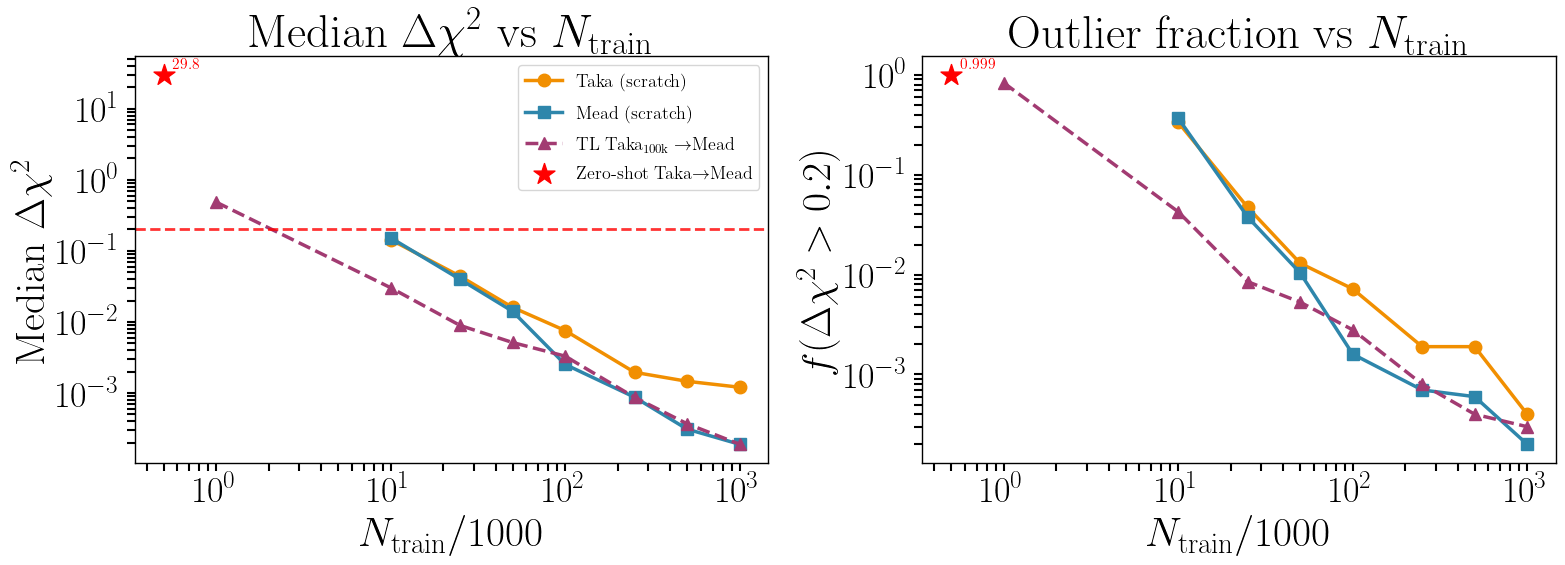

In [24]:
# ============================================================================
# PLOT: SCALING CURVES
# Median Δχ² and outlier fraction f(Δχ²>0.2) vs N_train on log-log axes.
# Shows all loaded groups on the same panel — good for comparing TL efficiency.
#
# Control which groups appear by editing SCALING_GROUPS.
# Zero-shot point is plotted as a red star at the left edge.
# ============================================================================

# Groups to include in the scaling plot — order controls legend order
# Set to None to include everything in `results`
SCALING_GROUPS = ['taka', 'mead', 'tl', 'tl_taka50k', 'tl_taka250k', 'tl_early2']


def plot_scaling(groups=SCALING_GROUPS, show_zeroshot=True, save=False, fname='scaling_combined.pdf'):
    """
    Log-log scaling curves for all specified groups.
    `groups`: list of group keys to plot (in order); None = all loaded groups.
    `show_zeroshot`: overlay dc2_zeroshot as a red star (requires zero-shot cell to have run).
    """
    groups_to_plot = groups if groups is not None else list(results.keys())
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for group in groups_to_plot:
        if group not in results or not results[group]:
            continue
        sizes   = sorted(results[group].keys())
        sizes_k = [n / 1000 for n in sizes]
        medians = [np.median(results[group][n]) for n in sizes]
        frac    = [np.mean(results[group][n] > 0.2) for n in sizes]
        sty     = GROUP_STYLES[group]
        kw = dict(linewidth=2.5, markersize=9, label=GROUP_LABELS[group],
                  color=sty['color'], marker=sty['marker'], linestyle=sty['linestyle'])
        axes[0].plot(sizes_k, medians, **kw)
        axes[1].plot(sizes_k, frac,    **kw)

    if show_zeroshot and 'dc2_zeroshot' in globals():
        zs_med  = np.median(dc2_zeroshot)
        zs_frac = np.mean(dc2_zeroshot > 0.2)
        zs_x    = 0.5   # left of N=1k on log scale
        axes[0].scatter([zs_x], [zs_med],  color='red', marker='*', s=250,
                        zorder=5, label=r'Zero-shot Taka$\to$Mead', clip_on=False)
        axes[1].scatter([zs_x], [zs_frac], color='red', marker='*', s=250,
                        zorder=5, clip_on=False)
        axes[0].annotate(f'{zs_med:.1f}', xy=(zs_x, zs_med),
                         xytext=(6, 5), textcoords='offset points', fontsize=11, color='red')
        axes[1].annotate(f'{zs_frac:.3f}', xy=(zs_x, zs_frac),
                         xytext=(6, 5), textcoords='offset points', fontsize=11, color='red')

    for ax in axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm train}\;/\;1000$')
        ax.tick_params(direction='out', length=6, width=1.5, which='both')

    axes[0].axhline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.8)
    axes[0].legend(fontsize=13, loc='upper right')
    axes[0].set_ylabel(r'Median $\Delta\chi^2$')
    axes[0].set_title(r'Median $\Delta\chi^2$ vs $N_{\rm train}$')
    axes[1].set_ylabel(r'$f(\Delta\chi^2 > 0.2)$')
    axes[1].set_title(r'Outlier fraction vs $N_{\rm train}$')
    plt.tight_layout()

    if save:
        fpath = OUTPUT_DIR / fname
        plt.savefig(fpath, bbox_inches='tight', dpi=300, pad_inches=0.05)
        print(f'Saved: {fpath}')
    plt.show()


# Default: full comparison
plot_scaling(groups=['taka', 'mead', 'tl'], show_zeroshot=True)

# Example: init model quality only (no freeze strategy lines)
# plot_scaling(groups=['taka', 'mead', 'tl_taka50k', 'tl', 'tl_taka250k'],
#              fname='scaling_init_model_comparison.pdf')

## ResMLP Experiments

Scaling curves and comparisons for the ResMLP architecture.
- **Scratch baselines**: Taka and Mead trained from scratch with ResMLP
- **TL**: Taka ResMLP pretrained → fine-tuned on Mead, varying init quality (50k/100k/250k/500k)
- **CNN vs ResMLP**: Direct scratch comparison to assess architectural gain


In [ ]:
# ============================================================================
# PLOT: ResMLP SCALING CURVES (scratch + TL)
# ResMLP-only view — scratch baselines and all TL init variants.
# ============================================================================

RESMLP_SCRATCH_GROUPS = ['taka_resmlp', 'mead_resmlp']
RESMLP_TL_GROUPS      = ['tl_resmlp_taka50k', 'tl_resmlp_taka100k',
                          'tl_resmlp_taka250k', 'tl_resmlp_taka500k']

# Scratch only
plot_scaling(
    groups=RESMLP_SCRATCH_GROUPS,
    show_zeroshot=False,
    save=True,
    fname='scaling_resmlp_scratch.pdf',
)

# Scratch + TL together
plot_scaling(
    groups=RESMLP_SCRATCH_GROUPS + RESMLP_TL_GROUPS,
    show_zeroshot=False,
    save=True,
    fname='scaling_resmlp_full.pdf',
)


In [ ]:
# ============================================================================
# PLOT: CNN vs ResMLP SCRATCH COMPARISON
# Taka CNN vs Taka ResMLP, Mead CNN vs Mead ResMLP — same axes, two panels.
# ============================================================================

def plot_cnn_vs_resmlp(save=False, fname='scaling_cnn_vs_resmlp_scratch.pdf'):
    """
    2-panel log-log: left=Taka pair, right=Mead pair.
    Solid line = CNN, dashed = ResMLP.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pairs = [
        ('taka', 'taka_resmlp', axes[0], 'Taka'),
        ('mead', 'mead_resmlp', axes[1], 'Mead'),
    ]
    for cnn_key, mlp_key, ax, title in pairs:
        for key in [cnn_key, mlp_key]:
            if key not in results or not results[key]:
                continue
            sizes   = sorted(results[key].keys())
            sizes_k = [n / 1000 for n in sizes]
            medians = [np.median(results[key][n]) for n in sizes]
            sty = GROUP_STYLES[key]
            ax.plot(sizes_k, medians,
                    linewidth=2.5, markersize=9,
                    label=GROUP_LABELS[key],
                    color=sty['color'], marker=sty['marker'],
                    linestyle=sty['linestyle'])
        ax.axhline(0.2, color='red', linestyle='--', linewidth=2, alpha=0.8,
                   label=r'$\Delta\chi^2 = 0.2$')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm train}\;/\;1000$')
        ax.set_ylabel(r'Median $\Delta\chi^2$')
        ax.set_title(title, fontsize=20)
        ax.tick_params(direction='out', length=6, width=1.5, which='both')
        ax.legend(fontsize=13, loc='upper right')
    fig.suptitle(r'CNN vs ResMLP: Scratch Baselines', fontsize=20, y=1.01)
    plt.tight_layout()
    if save:
        fpath = OUTPUT_DIR / fname
        plt.savefig(fpath, bbox_inches='tight', dpi=300, pad_inches=0.05)
        print(f'Saved: {fpath}')
    plt.show()


plot_cnn_vs_resmlp(save=True)


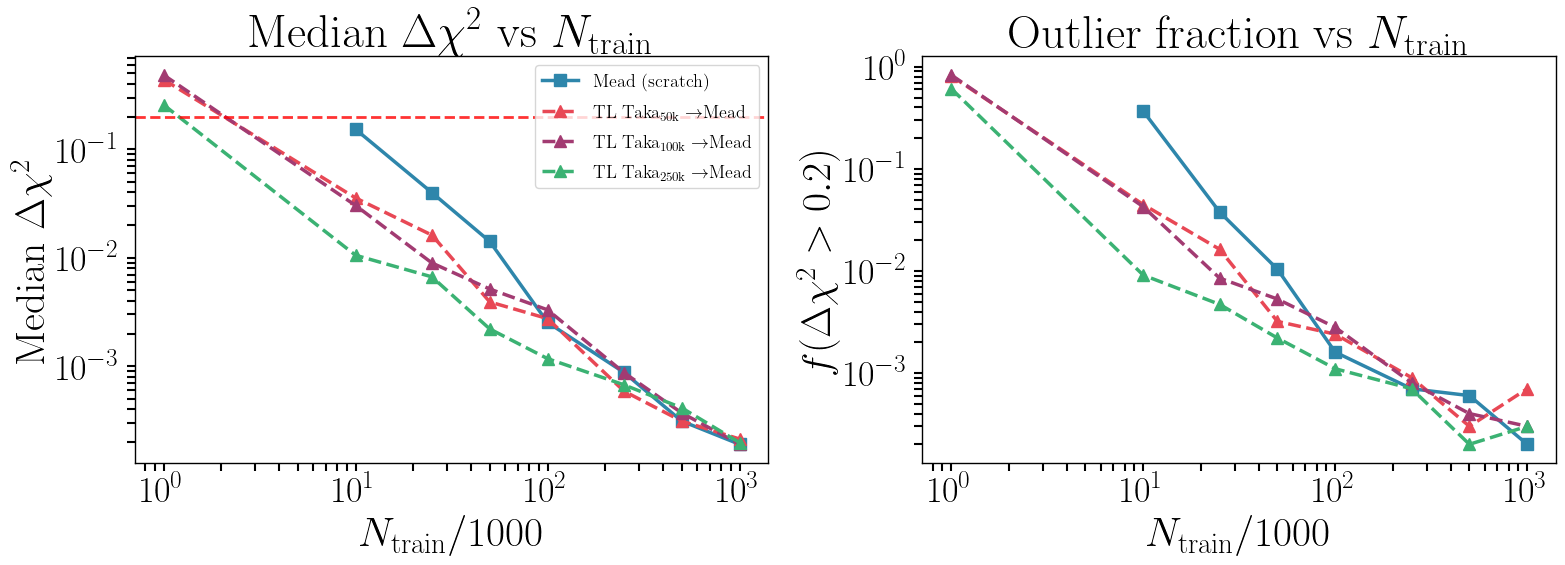

In [8]:
# ============================================================================
# PLOT: INIT MODEL QUALITY COMPARISON
# Focused version of the scaling plot — shows only the three TL lines
# (Taka 50k, 100k, 250k as pretrained model) against the Mead scratch baseline.
# This is the main plot for Vivian's question about pretrained model quality.
# ============================================================================
plot_scaling(
    groups=['mead', 'tl_taka50k', 'tl', 'tl_taka250k'],
    show_zeroshot=True,
    fname='scaling_init_model_comparison.pdf'
)

Saved: /home/grads/tmp/roman_cs_baseline/output_combined/freeze_sweep_all.pdf


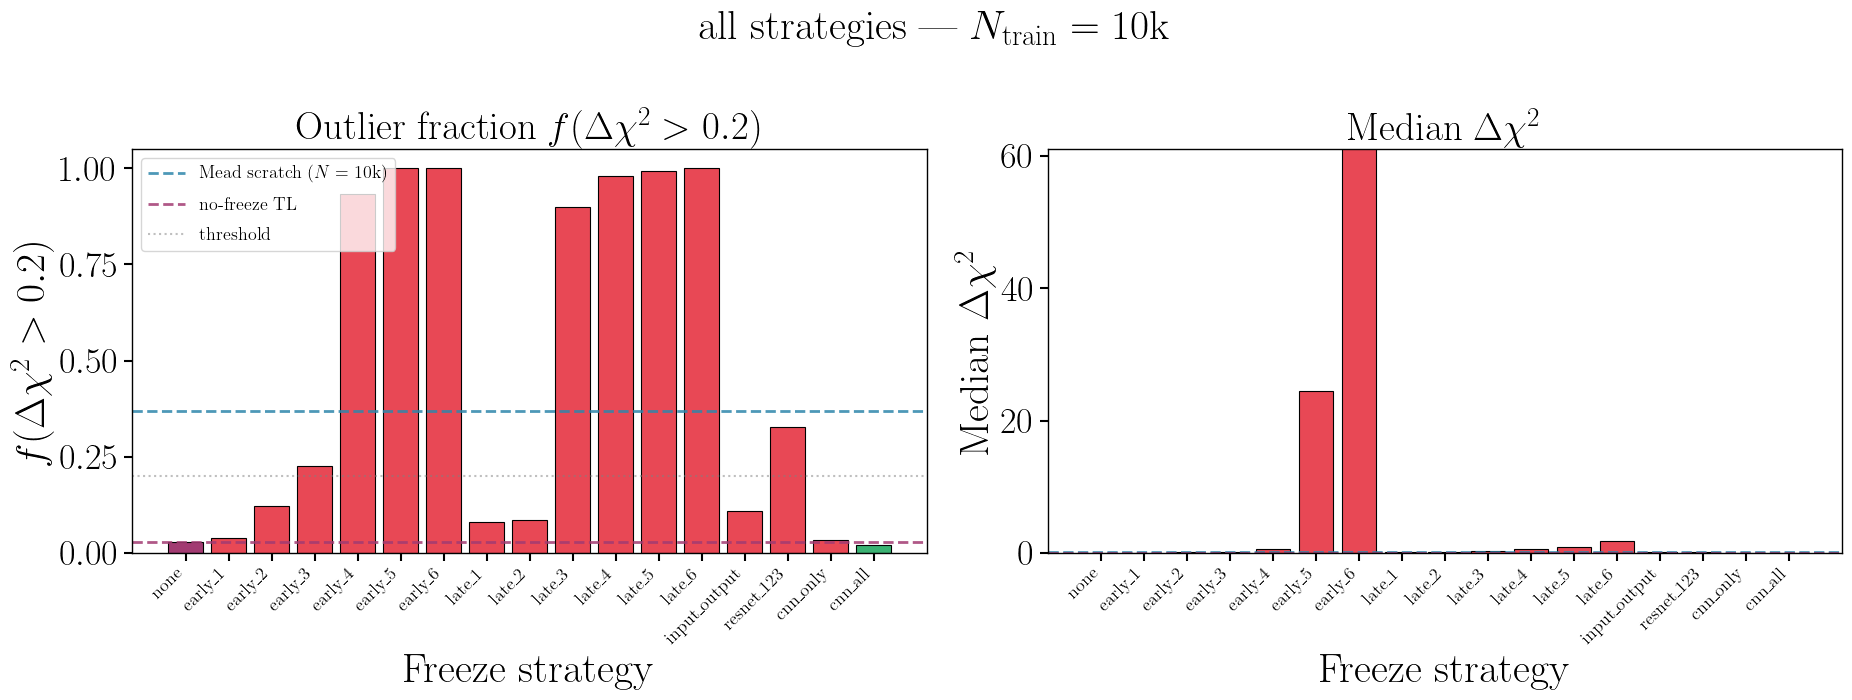

Saved: /home/grads/tmp/roman_cs_baseline/output_combined/freeze_sweep_early.pdf


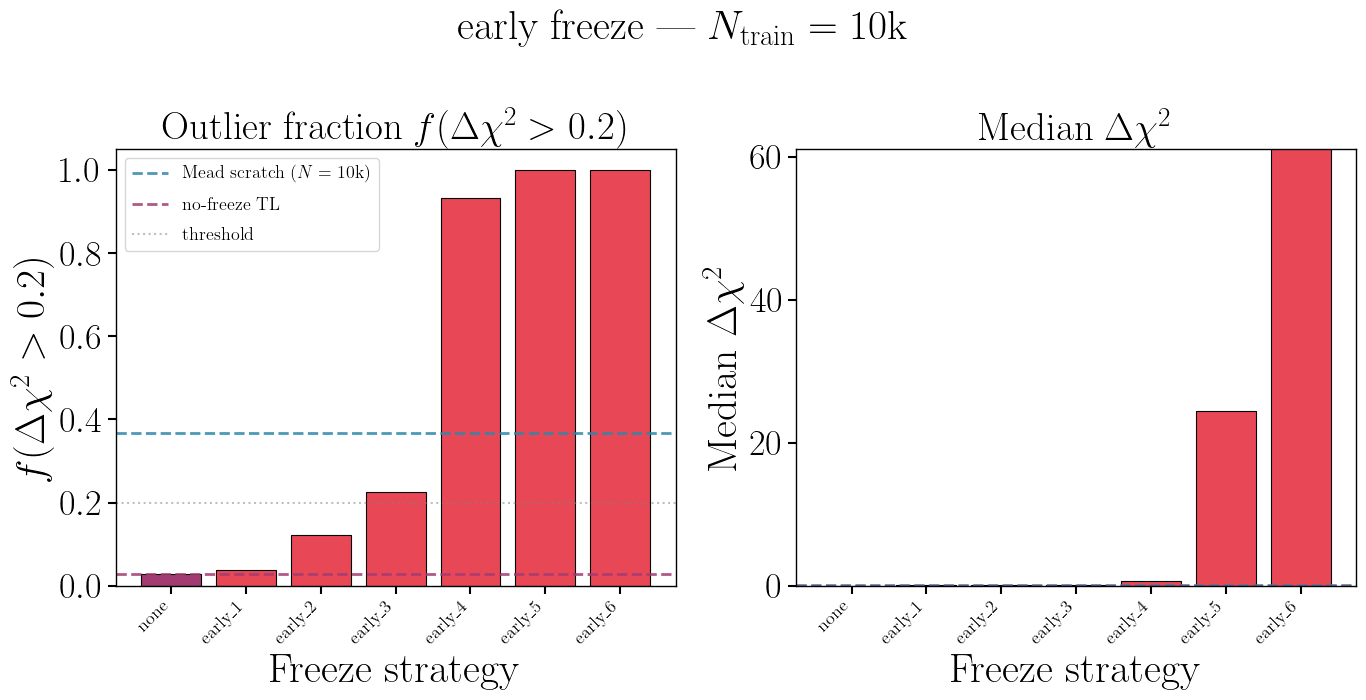

Saved: /home/grads/tmp/roman_cs_baseline/output_combined/freeze_sweep_late.pdf


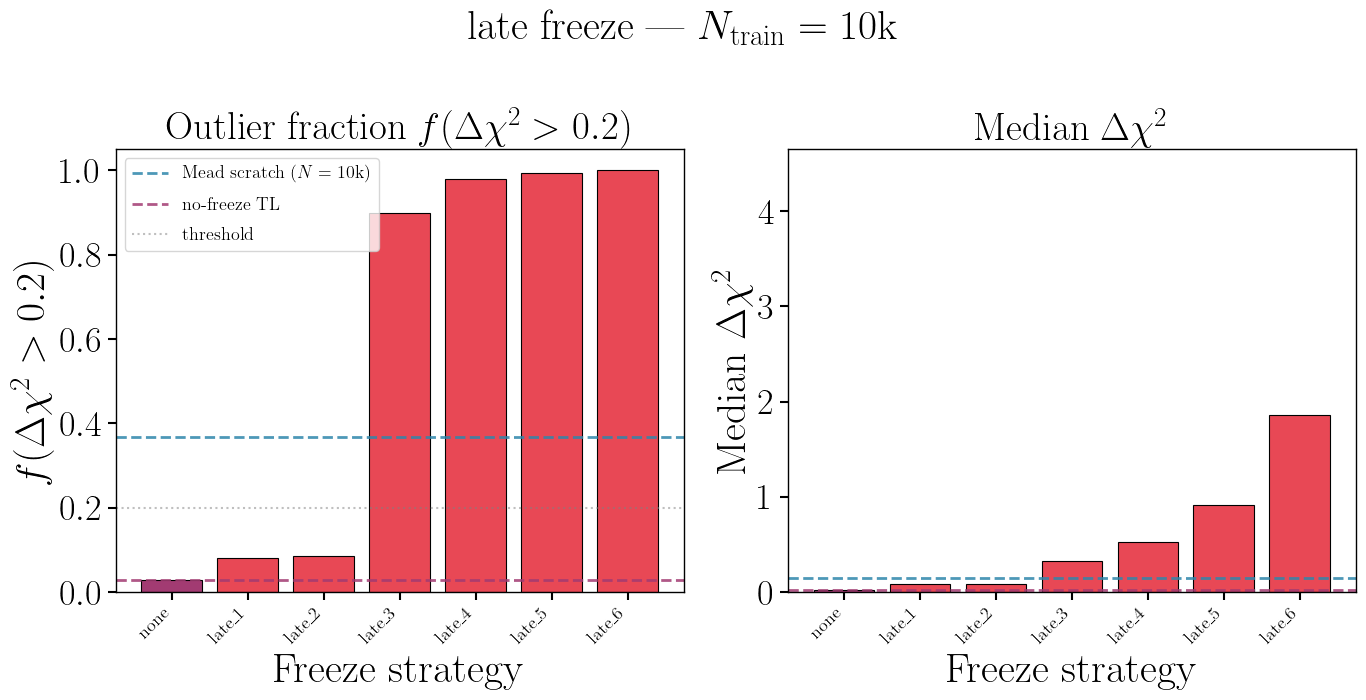

Saved: /home/grads/tmp/roman_cs_baseline/output_combined/freeze_sweep_other.pdf


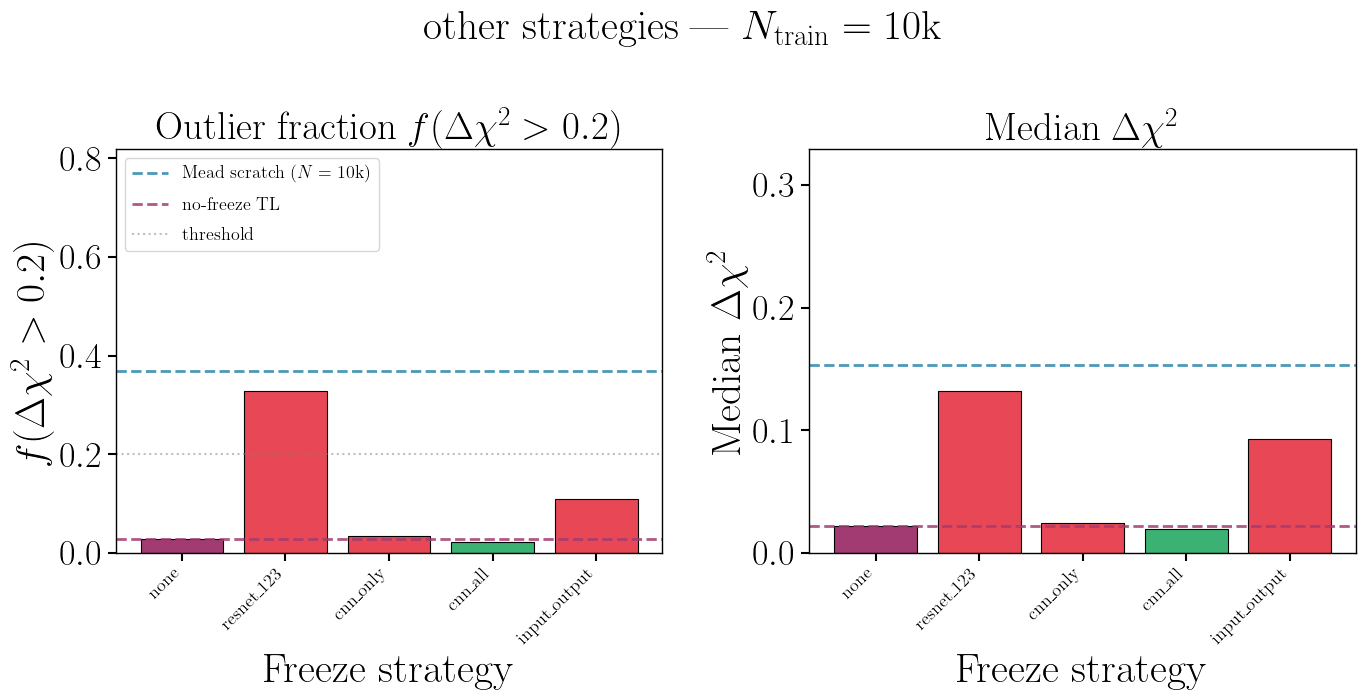

Saved: /home/grads/tmp/roman_cs_baseline/output_combined/freeze_sweep_best5.pdf


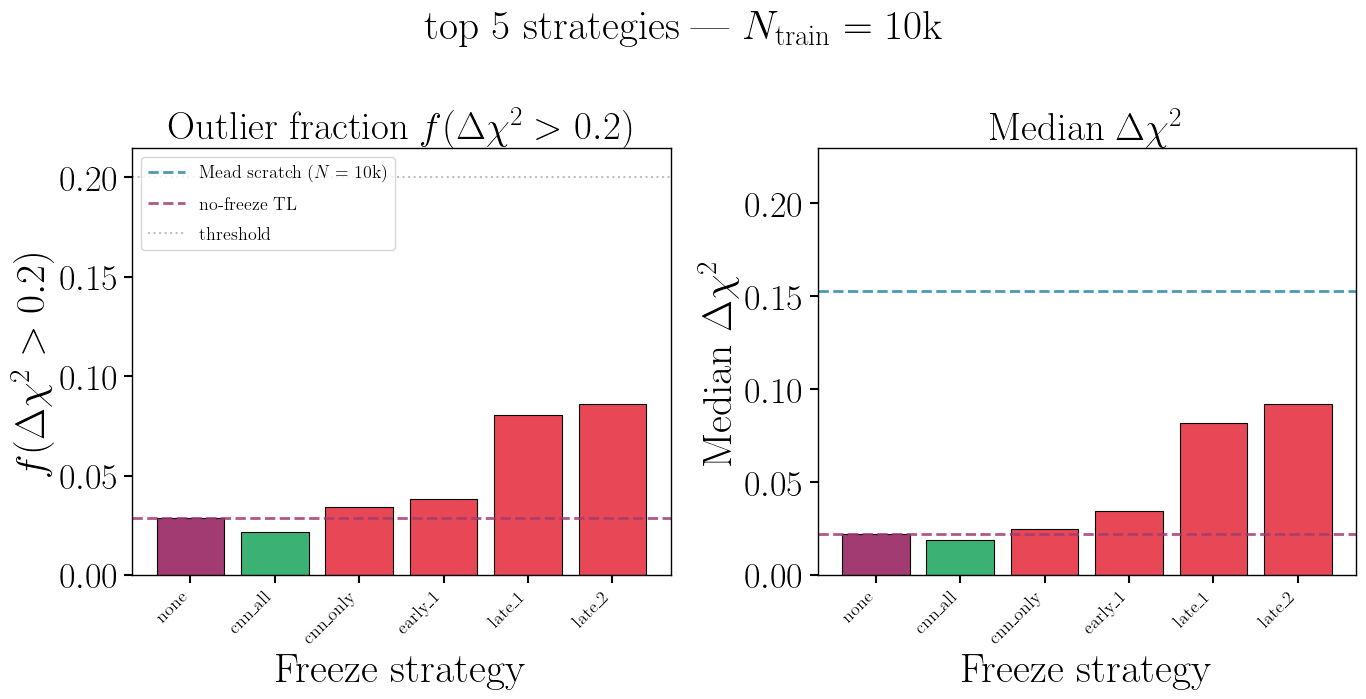

In [22]:
# ============================================================================
# PLOT: FREEZE STRATEGY BAR CHARTS
# Shows f(Δχ²>0.2) and median Δχ² per freeze strategy at fixed N_train.
#
# Reference lines drawn for context:
#   - zero-shot: Taka 1M model evaluated on Mead test data with no fine-tuning
#   - mead scratch: Mead model trained from scratch at same N_train
#   - no-freeze TL: the no-freeze fine-tuning result (from freeze_results['none'])
#
# Call plot_freeze_sweep() with different `subset` args to get different views:
#   subset=None        → all strategies together
#   subset='early'     → early_1 through early_6 only
#   subset='late'      → late_1 through late_6 only
#   subset='other'     → resnet, cnn, input_output variants
#   subset='best'      → top N strategies by f(>0.2), set n_best below
# ============================================================================

N_BEST = 5   # how many strategies to show in 'best' view

# Strategy family groupings
_EARLY   = [f'early_{i}' for i in range(1, 7)]
_LATE    = [f'late_{i}'  for i in range(1, 7)]
_OTHER   = ['resnet_123', 'cnn_only', 'cnn_all', 'input_output']


def _get_reference_lines():
    """
    Returns dict of reference values to draw as horizontal lines.
    Each entry: label -> (frac, median, color, linestyle)
    Falls back gracefully if a reference isn't loaded.
    """
    refs = {}

    # Zero-shot: pre-TL model on mead test data
    if 'dc2_zeroshot' in dir() and dc2_zeroshot is not None:
        refs['zero-shot (pre-TL)'] = (
            np.mean(dc2_zeroshot > 0.2),
            np.median(dc2_zeroshot),
            '#CC0000', ':'
        )

    # Mead scratch at same N_train as the freeze sweep
    if 'mead' in results and FREEZE_SWEEP_N_TRAIN in results['mead']:
        dc2_mead = results['mead'][FREEZE_SWEEP_N_TRAIN]
        refs[rf'Mead scratch ($N={fmt_n(FREEZE_SWEEP_N_TRAIN)}$)'] = (
            np.mean(dc2_mead > 0.2),
            np.median(dc2_mead),
            '#2E86AB', '--'
        )

    # No-freeze TL baseline
    if 'none' in freeze_results:
        dc2_none = freeze_results['none']
        refs['no-freeze TL'] = (
            np.mean(dc2_none > 0.2),
            np.median(dc2_none),
            '#A23B72', '--'
        )

    return refs


def plot_freeze_sweep(subset=None, save=False, fname=None):
    """
    Bar chart of freeze strategy performance.

    subset: None       → all strategies
            'early'    → early_1 to early_6
            'late'     → late_1 to late_6
            'other'    → resnet/cnn/input_output variants
            'best'     → top N_BEST strategies by f(>0.2)
            list       → explicit list of strategy keys

    Always includes 'none' (no-freeze) as a purple reference bar.
    Reference lines: zero-shot, mead scratch, no-freeze TL.
    Bars colored green if better than no-freeze, red if worse, purple for 'none' itself.
    """
    if not freeze_results:
        print('No freeze sweep results loaded. Set INCLUDE_FREEZE_SWEEP = True and re-run the freeze loading cell.')
        return

    # Build strategy list for this view
    if subset is None:
        strategies = [s for s in FREEZE_SWEEP_STRATEGIES if s in freeze_results and s != 'none']
        title_tag  = 'all strategies'
        fname      = fname or 'freeze_sweep_all.pdf'
    elif subset == 'early':
        strategies = [s for s in _EARLY if s in freeze_results]
        title_tag  = 'early freeze'
        fname      = fname or 'freeze_sweep_early.pdf'
    elif subset == 'late':
        strategies = [s for s in _LATE if s in freeze_results]
        title_tag  = 'late freeze'
        fname      = fname or 'freeze_sweep_late.pdf'
    elif subset == 'other':
        strategies = [s for s in _OTHER if s in freeze_results]
        title_tag  = 'other strategies'
        fname      = fname or 'freeze_sweep_other.pdf'
    elif subset == 'best':
        all_s = [s for s in freeze_results if s != 'none']
        all_s.sort(key=lambda s: np.mean(freeze_results[s] > 0.2))
        strategies = all_s[:N_BEST]
        title_tag  = f'top {N_BEST} strategies'
        fname      = fname or f'freeze_sweep_best{N_BEST}.pdf'
    elif isinstance(subset, list):
        strategies = [s for s in subset if s in freeze_results and s != 'none']
        title_tag  = 'selected strategies'
        fname      = fname or 'freeze_sweep_custom.pdf'
    else:
        raise ValueError(f'Unknown subset: {subset!r}')

    # Always prepend 'none' as reference bar
    if 'none' in freeze_results:
        strategies = ['none'] + strategies

    frac    = [np.mean(freeze_results[s] > 0.2) for s in strategies]
    medians = [np.median(freeze_results[s])      for s in strategies]

    none_frac_v   = frac[0]    if 'none' in strategies else None
    none_median_v = medians[0] if 'none' in strategies else None

    # Bar colors
    colors = []
    for s, fv in zip(strategies, frac):
        if s == 'none':
            colors.append('#A23B72')   # purple — reference
        elif none_frac_v is not None and fv <= none_frac_v:
            colors.append('#3BB273')   # green — beats no-freeze
        else:
            colors.append('#E84855')   # red — worse than no-freeze

    refs = _get_reference_lines()

    fig, axes = plt.subplots(1, 2, figsize=(max(14, len(strategies) * 1.1), 7))
    x = np.arange(len(strategies))

    axes[0].bar(x, frac,    color=colors, edgecolor='black', linewidth=0.8)
    axes[1].bar(x, medians, color=colors, edgecolor='black', linewidth=0.8)

    # Draw reference lines on both panels
    for label, (rfrac, rmedian, color, ls) in refs.items():
        axes[0].axhline(rfrac,   color=color, linestyle=ls, linewidth=2, label=label, alpha=0.85)
        axes[1].axhline(rmedian, color=color, linestyle=ls, linewidth=2,              alpha=0.85)

    axes[0].axhline(0.2, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='threshold')

    # Zoom y-axis to the interesting range — clip catastrophic failures
    good_frac    = [f for f in frac    if f < 0.95]
    good_medians = [m for m in medians if m < 50]
    axes[0].set_ylim(0, min(1.05, max(good_frac)    * 2.5) if good_frac    else 1.05)
    axes[1].set_ylim(0, max(good_medians) * 2.5           if good_medians else 1.0)

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(strategies, rotation=45, ha='right', fontsize=13)
        ax.set_xlabel('Freeze strategy')
        ax.tick_params(direction='out', length=6, width=1.5)

    axes[0].legend(fontsize=13, loc='upper left')
    axes[0].set_ylabel(r'$f(\Delta\chi^2 > 0.2)$')
    axes[1].set_ylabel(r'Median $\Delta\chi^2$')
    fig.suptitle(rf'{title_tag} — $N_{{\rm train}}={fmt_n(FREEZE_SWEEP_N_TRAIN)}$', fontsize=30, y=1.01)
    axes[0].set_title(r'Outlier fraction $f(\Delta\chi^2 > 0.2)$', fontsize=28)
    axes[1].set_title(r'Median $\Delta\chi^2$', fontsize=28)
    plt.tight_layout()

    if save:
        fpath = OUTPUT_DIR / fname
        plt.savefig(fpath, bbox_inches='tight', dpi=300, pad_inches=0.05)
        print(f'Saved: {fpath}')
    plt.show()


# All strategies together
plot_freeze_sweep(subset=None, save=True)

# Uncomment to generate individual views:
plot_freeze_sweep(subset='early', save=True)
plot_freeze_sweep(subset='late', save=True)
plot_freeze_sweep(subset='other', save=True)
plot_freeze_sweep(subset='best', save=True)


In [10]:
# ============================================================================
# SUMMARY TABLE
# Prints median Δχ², mean Δχ², and f(>0.2) for all loaded groups and N_train values.
# ⚠ flags indicate mismatch between inference result and training log (>0.01 difference).
# ============================================================================
all_groups = ['taka', 'mead', 'tl', 'tl_early2', 'tl_taka50k', 'tl_taka250k']

print(f'{"Group":<14} {"N_train":>10} {"Median":>10} {"Mean":>10} {"f>0.2":>7}')
print('-' * 58)
for group in all_groups:
    if group not in results:
        continue
    for n in sorted(results[group].keys()):
        dc2     = results[group][n]
        inf_med = np.median(dc2)
        flag    = ''
        if n in log_results.get(group, {}):
            log_med = log_results[group][n].get('median', float('nan'))
            if not np.isnan(log_med) and abs(inf_med - log_med) > 0.01:
                flag = ' ⚠'
        print(f'{group:<14} {n:>10,} {inf_med:>10.4f} {np.mean(dc2):>10.4f} {np.mean(dc2 > 0.2):>7.3f}{flag}')
    print()

# Freeze sweep summary
if freeze_results:
    print(f'\n{"Strategy":<20} {"Median":>10} {"Mean":>10} {"f>0.2":>7}')
    print('-' * 52)
    for strategy in FREEZE_SWEEP_STRATEGIES:
        if strategy not in freeze_results:
            continue
        dc2 = freeze_results[strategy]
        print(f'{strategy:<20} {np.median(dc2):>10.4f} {np.mean(dc2):>10.4f} {np.mean(dc2 > 0.2):>7.3f}')

Group             N_train     Median       Mean   f>0.2
----------------------------------------------------------
taka               10,000     0.1439     1.5058   0.335
taka               25,000     0.0440     0.1798   0.047
taka               50,000     0.0160     0.0665   0.013
taka              100,000     0.0076     0.0290   0.007
taka              250,000     0.0020     0.0094   0.002
taka              500,000     0.0015     0.0057   0.002
taka            1,000,000     0.0012     0.0027   0.000

mead               10,000     0.1530     0.3857   0.368
mead               25,000     0.0398     0.0948   0.038
mead               50,000     0.0141     0.0416   0.010
mead              100,000     0.0025     0.0057   0.002
mead              250,000     0.0009     0.0020   0.001
mead              500,000     0.0003     0.0008   0.001
mead            1,000,000     0.0002     0.0006   0.000

tl                  1,000     0.4851    16.5917   0.833
tl                 10,000     0.0303     0.